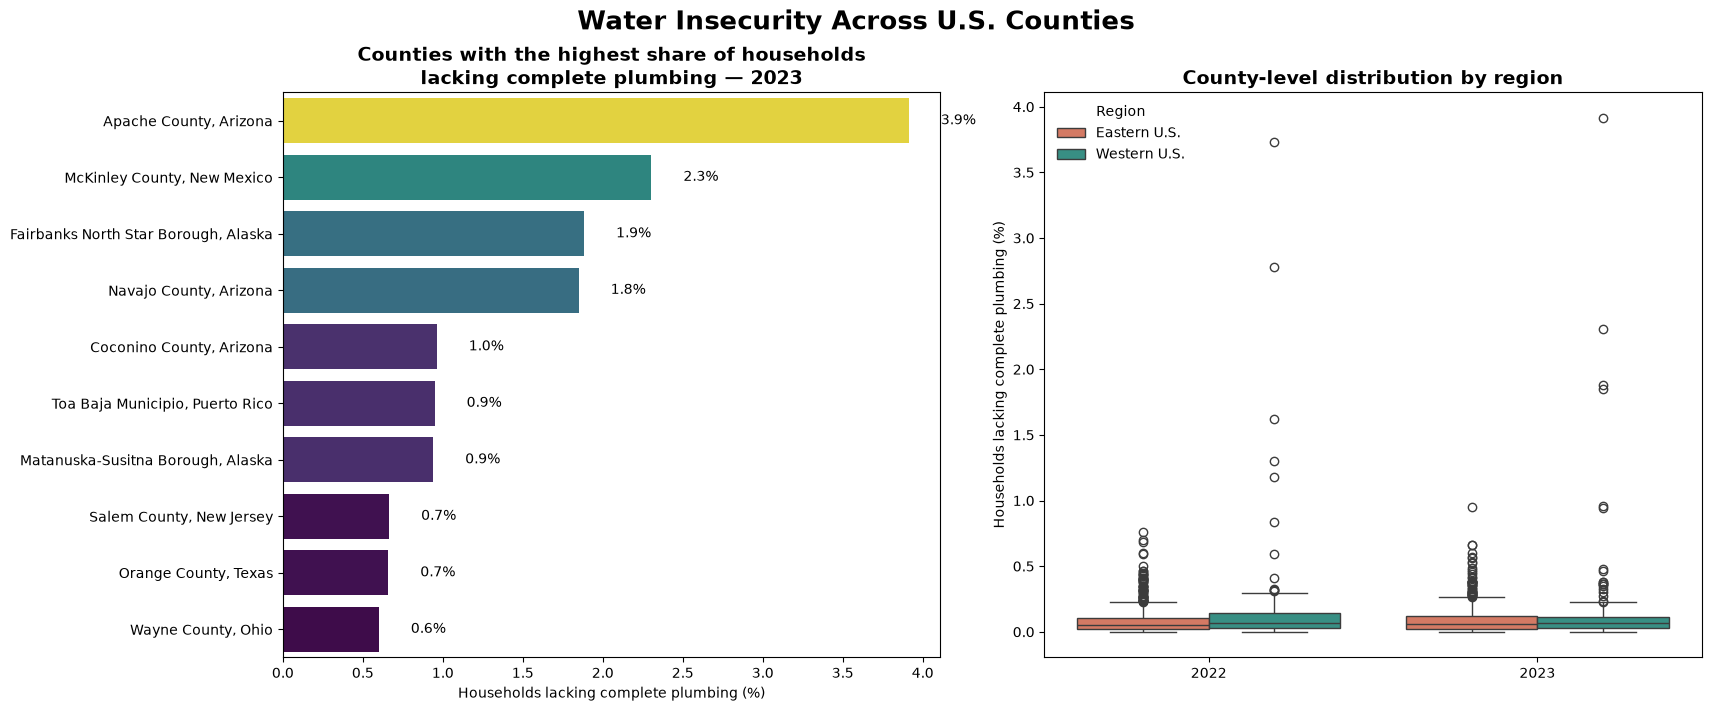

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# --- Read the county-level ACS data directly from TidyTuesday ---
url_2022 = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-01-28/water_insecurity_2022.csv"
url_2023 = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-01-28/water_insecurity_2023.csv"

water_insecurity_2022 = pd.read_csv(url_2022)
water_insecurity_2023 = pd.read_csv(url_2023)

# --- Standardize GEOID ---
for data in [water_insecurity_2022, water_insecurity_2023]:
    data["geoid"] = data["geoid"].astype(str).str.zfill(5)
    data["state_fips"] = data["geoid"].str[:2]

# --- Add year and combine ---
water_insecurity_2022["year"] = 2022
water_insecurity_2023["year"] = 2023

df = pd.concat(
    [water_insecurity_2022, water_insecurity_2023],
    ignore_index=True
)

# --- Make sure percentage is numeric ---
df["percent_lacking_plumbing"] = pd.to_numeric(
    df["percent_lacking_plumbing"],
    errors="coerce"
)

# Remove rows where the value is missing
df = df.dropna(subset=["percent_lacking_plumbing"])

# --- Define Western vs Eastern U.S. counties ---
west_states = {
    "02", "04", "06", "08", "15", "16",
    "30", "32", "35", "41", "49", "53", "56"
}

df["region"] = np.where(
    df["state_fips"].isin(west_states),
    "Western U.S.",
    "Eastern U.S."
)

# --- Top counties in 2023 ---
top_10 = (
    df[df["year"] == 2023]
    .sort_values(
        "percent_lacking_plumbing",
        ascending=False
    )
    .head(10)
    .copy()
)

# --- Plot ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 7),
    constrained_layout=True
)

# =========================================================
# Plot 1 — Top 10 counties
# =========================================================

sns.barplot(
    data=top_10,
    x="percent_lacking_plumbing",
    y="name",
    hue="percent_lacking_plumbing",
    palette="viridis",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Counties with the highest share of households\nlacking complete plumbing — 2023",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Households lacking complete plumbing (%)")
axes[0].set_ylabel("")

# Add values to bars
for i, value in enumerate(top_10["percent_lacking_plumbing"]):
    axes[0].text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

# =========================================================
# Plot 2 — Distribution by region
# =========================================================

sns.boxplot(
    data=df,
    x="year",
    y="percent_lacking_plumbing",
    hue="region",
    palette={
        "Western U.S.": "#2a9d8f",
        "Eastern U.S.": "#e76f51"
    },
    ax=axes[1]
)

axes[1].set_title(
    "County-level distribution by region",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("Households lacking complete plumbing (%)")
axes[1].legend(
    title="Region",
    frameon=False
)

# --- Overall title ---
fig.suptitle(
    "Water Insecurity Across U.S. Counties",
    fontsize=19,
    fontweight="bold"
)

plt.show()